In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms

In [2]:
BATCH_SIZE = 64 # number of images passed through the network at once
LEARNING_RATE = 0.001 # how big of a step the optimizer takes to update the parameters
EPOCHS = 5 # number of times we will loop over the training data

In [3]:
transform = transforms.Compose([transforms.ToTensor()]) # transforms an image into an array of numbers
# it converts the raw pixel values (0 to 255) into pytorch tensors (arrays)
# and scales them to a range of [0, 1]

# download and load training data:
train_dataset = torchvision.datasets.MNIST(
    root = "./data",
    train = True,
    download = True,
    transform = transform
)

test_dataset = torchvision.datasets.MNIST(
    root = "./data",
    train = False,
    download = True,
    transform = transform
)

100%|██████████| 9.91M/9.91M [00:02<00:00, 4.67MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 127kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.22MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 13.0MB/s]


In [4]:
train_loader = torch.utils.data.DataLoader(dataset = train_dataset,
                                           batch_size = BATCH_SIZE,
                                           shuffle = True)

test_loader = torch.utils.data.DataLoader(dataset = test_dataset,
                                          batch_size = BATCH_SIZE,
                                          shuffle = False)

In [5]:
class Classifier(nn.Module):

  def __init__(self):
    super(Classifier, self).__init__()

    # 1st step:
    self.flatten = nn.Flatten()

    # 2nd step: linear layer:
    self.fc1 = nn.Linear(28*28, 128)

    self.relu1 = nn.ReLU()

    self.fc2 = nn.Linear(128, 64)
    self.relu2 = nn.ReLU()

    self.output_layer = nn.Linear(64, 10)

  def forward(self, x):
    # the forward method defines how the data is passed through the network
    x = self.flatten(x)
    x = self.fc1(x)
    x = self.relu1(x)
    x = self.fc2(x)
    x = self.relu2(x)
    x = self.output_layer(x)
    return x


In [6]:
model = Classifier()

In [7]:
criterion = nn.CrossEntropyLoss()

In [8]:
optimizer = optim.Adam(model.parameters(), lr = LEARNING_RATE)

In [9]:
print("Starting Training ... \n")

for epoch in range(EPOCHS):

  running_loss = 0.0

  for images, labels in train_loader:

    optimizer.zero_grad()

    outputs = model(images)

    loss = criterion(outputs, labels)

    loss.backward()

    optimizer.step()

    running_loss = running_loss + loss.item()

  avg_loss = running_loss / len(train_loader)
  print(f"Epoch {epoch + 1}/{EPOCHS}, Loss: {avg_loss:.4f}")

print("Training Finished!")


Starting Training ... 

Epoch 1/5, Loss: 0.3344
Epoch 2/5, Loss: 0.1334
Epoch 3/5, Loss: 0.0913
Epoch 4/5, Loss: 0.0681
Epoch 5/5, Loss: 0.0554
Training Finished!


In [10]:
# --- 5. Evaluation ---

print("Starting Testing...")
# Put the model in evaluation mode (affects layers like Dropout/BatchNorm if used)
model.eval()

correct_predictions = 0
total_predictions = 0

# torch.no_grad() disables gradient tracking.
# We don't need gradients for testing, and disabling them saves memory and speeds up computation.
with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images)

        # outputs is a tensor of shape [batch_size, 10] (10 probabilities per image)
        # torch.max returns the highest value and its index. The index is our predicted class.
        _, predicted_class = torch.max(outputs, 1)

        total_predictions += labels.size(0)
        correct_predictions += (predicted_class == labels).sum().item()

accuracy = 100 * correct_predictions / total_predictions
print(f"Test Accuracy: {accuracy:.2f}%")

Starting Testing...
Test Accuracy: 97.48%


Peeking at a batch of training data...


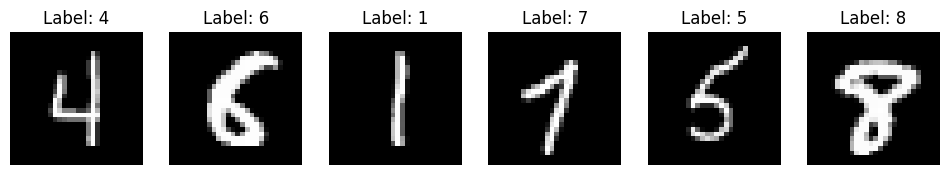

In [11]:
import matplotlib.pyplot as plt

# --- Peek at the Data ---
print("Peeking at a batch of training data...")

# Get a single batch of images and their labels
dataiter = iter(train_loader)
images, labels = next(dataiter)

# Create a figure to display 6 images
fig, axes = plt.subplots(1, 6, figsize=(12, 2))

for i in range(6):
    # PyTorch image tensors are shaped [Channels, Height, Width] -> [1, 28, 28].
    # Matplotlib expects 2D arrays for grayscale, so we use .squeeze()
    # to remove the channel dimension: [1, 28, 28] becomes [28, 28].
    img = images[i].squeeze()

    axes[i].imshow(img, cmap='gray')
    axes[i].set_title(f"Label: {labels[i].item()}")
    axes[i].axis('off') # Hide the axes for a cleaner look

plt.show()

# Try it on numbers you write yourself !

In [12]:
from PIL import Image, ImageOps

# --- Inference on Custom Images ---

def predict_custom_image(image_path, trained_model):
    """Loads a user-drawn image, formats it for MNIST, and predicts the digit."""

    # 1. Load the image
    img = Image.open(image_path)

    # 2. Preprocess to match MNIST exactly
    # Convert to grayscale (removes RGB color channels)
    img = img.convert('L')

    # INVERT COLORS: This is crucial!
    # People usually draw with black ink on a white canvas.
    # MNIST data is white ink on a black background.
    img = ImageOps.invert(img)

    # Resize to the 28x28 pixels our model expects
    img = img.resize((28, 28))

    # Convert to PyTorch tensor and scale to [0, 1]
    transform = transforms.ToTensor()
    img_tensor = transform(img)

    # Add a batch dimension: [1, 28, 28] -> [1, 1, 28, 28]
    # The model expects a batch, even if it's a batch of 1
    img_tensor = img_tensor.unsqueeze(0)

    # 3. Make prediction
    trained_model.eval() # Ensure model is in evaluation mode
    with torch.no_grad():
        output = trained_model(img_tensor)

        # Find the highest value in the 10 outputs
        _, predicted_class = torch.max(output, 1)

    print(f"\n--- Custom Image Result ---")
    print(f"The model predicts this digit is: {predicted_class.item()}")

    # 4. Display the processed image so the user sees what the model sees
    plt.imshow(img_tensor.squeeze(), cmap='gray')
    plt.title(f"Predicted: {predicted_class.item()}")
    plt.axis('off')
    plt.show()

# --- Usage Example ---
# Have your drawn example number in MS Paint, save it as 'my_digit.png',
# drop it in the same folder as the script, and uncomment the line below:

# predict_custom_image('my_digit.png', model)